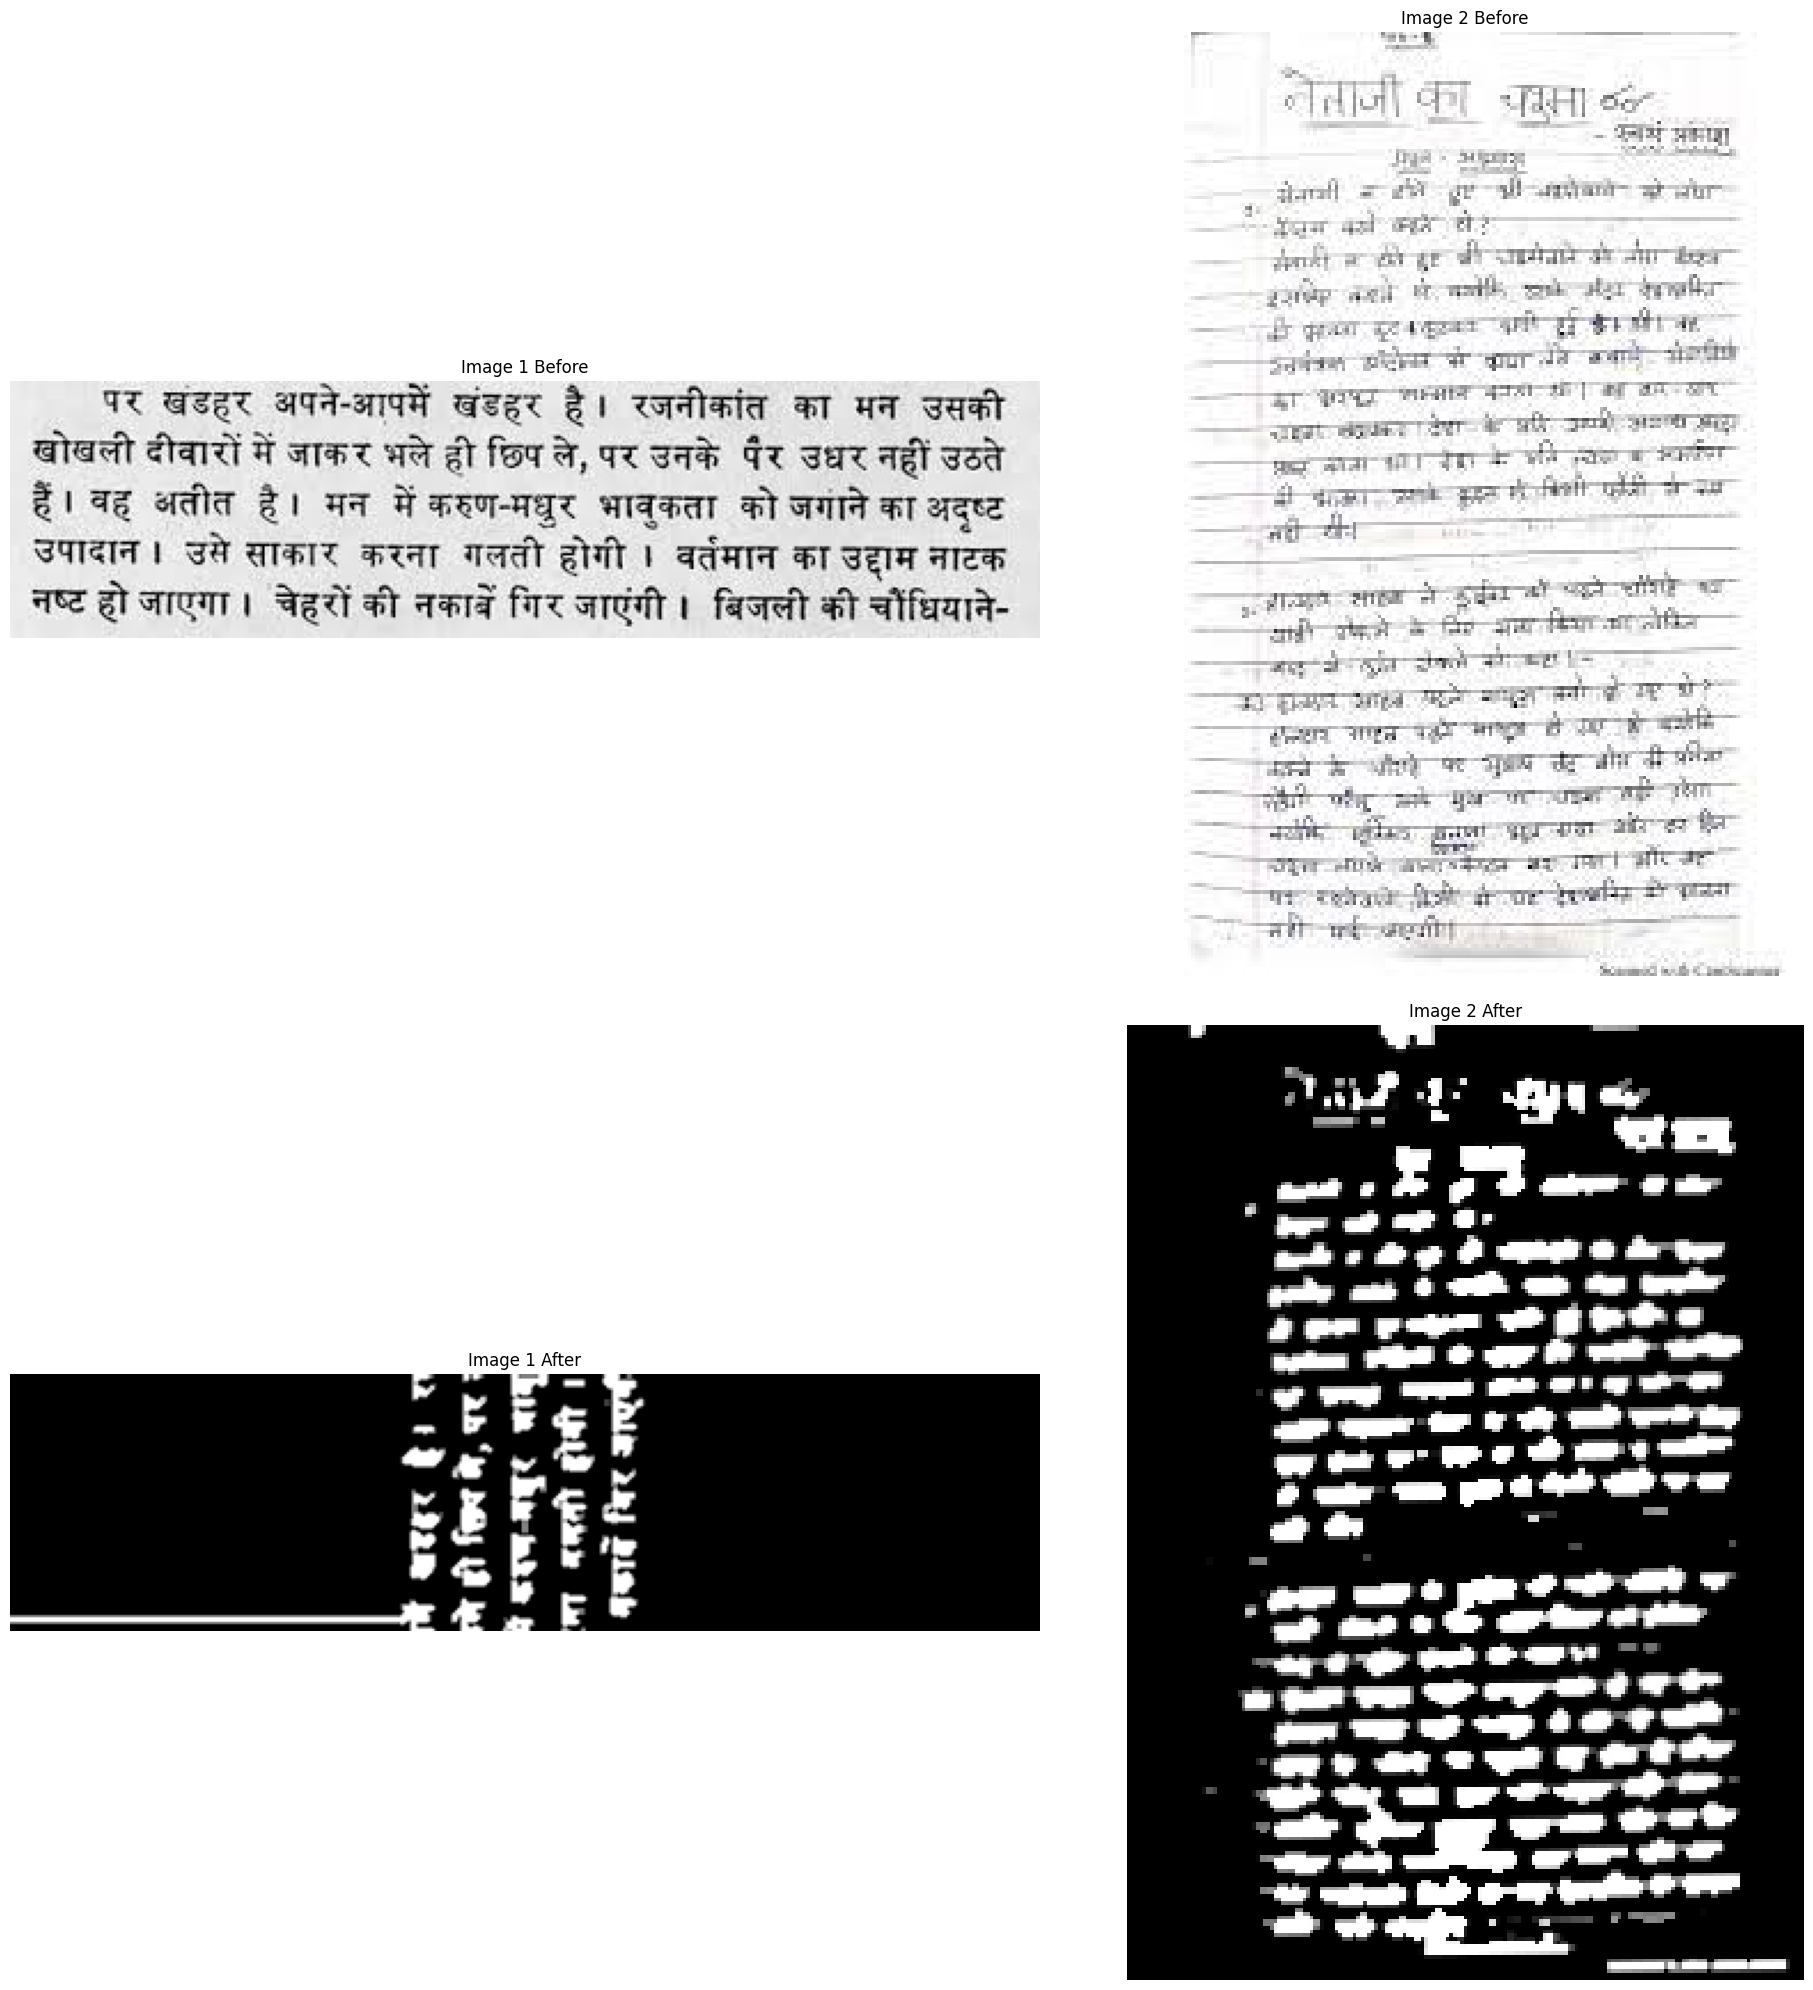

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
def preprocess_for_ocr(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    denoised = cv2.GaussianBlur(gray, (5,5), 0)
    _, binary = cv2.threshold(
        denoised, 0, 255,
        cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    # Deskew
    coords = np.column_stack(np.where(binary > 0))
    angle = cv2.minAreaRect(coords)[-1]
    angle += 90 if angle < -45 else 0
    M = cv2.getRotationMatrix2D(
        (binary.shape[1]/2, binary.shape[0]/2),
        angle, 1.0)
    deskewed = cv2.warpAffine(
        binary, M, (binary.shape[1], binary.shape[0]),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE)
    # Morphology
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (2,2))
    cleaned = cv2.morphologyEx(
        deskewed, cv2.MORPH_OPEN, kernel)
    return cleaned

# Load images
image_1_before = cv2.imread('download.jpeg')
image_2_before = cv2.imread('images.jpeg')
image_1_after = preprocess_for_ocr('download.jpeg')
image_2_after = preprocess_for_ocr('images.jpeg')

# Convert BGR → RGB for display with matplotlib
def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Prepare images for plotting
img1_bgr = image_1_before
img2_bgr = image_2_before

# If preprocess_for_ocr returns a binary image, it’s single‐channel; we can display it directly.
# Otherwise, if it’s still BGR/gray, handle accordingly.
img1_pre = image_1_after
img2_pre = image_2_after

# Create a 2×2 subplot
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# Top‐left: original image 1
axes[0, 0].imshow(bgr_to_rgb(img1_bgr))
axes[0, 0].set_title('Image 1 Before')
axes[0, 0].axis('off')

# Bottom‐left: preprocessed image 1
if len(img1_pre.shape) == 2:
    axes[1, 0].imshow(img1_pre, cmap='gray')
else:
    axes[1, 0].imshow(bgr_to_rgb(img1_pre))
axes[1, 0].set_title('Image 1 After')
axes[1, 0].axis('off')

# Top‐right: original image 2
axes[0, 1].imshow(bgr_to_rgb(img2_bgr))
axes[0, 1].set_title('Image 2 Before')
axes[0, 1].axis('off')

# Bottom‐right: preprocessed image 2
if len(img2_pre.shape) == 2:
    axes[1, 1].imshow(img2_pre, cmap='gray')
else:
    axes[1, 1].imshow(bgr_to_rgb(img2_pre))
axes[1, 1].set_title('Image 2 After')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


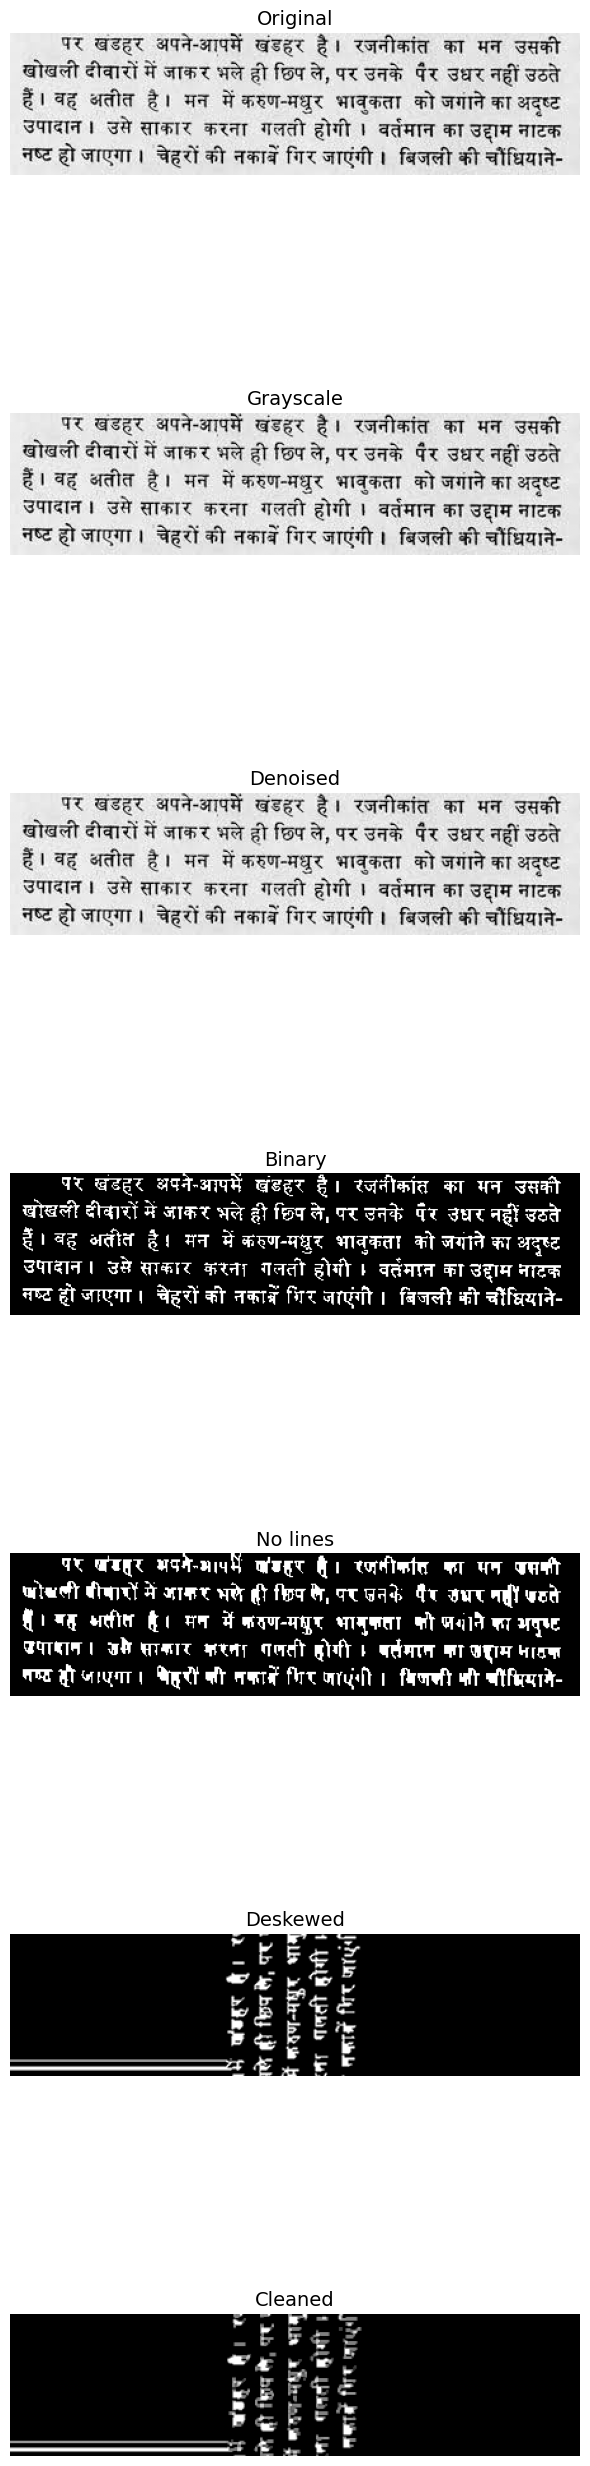

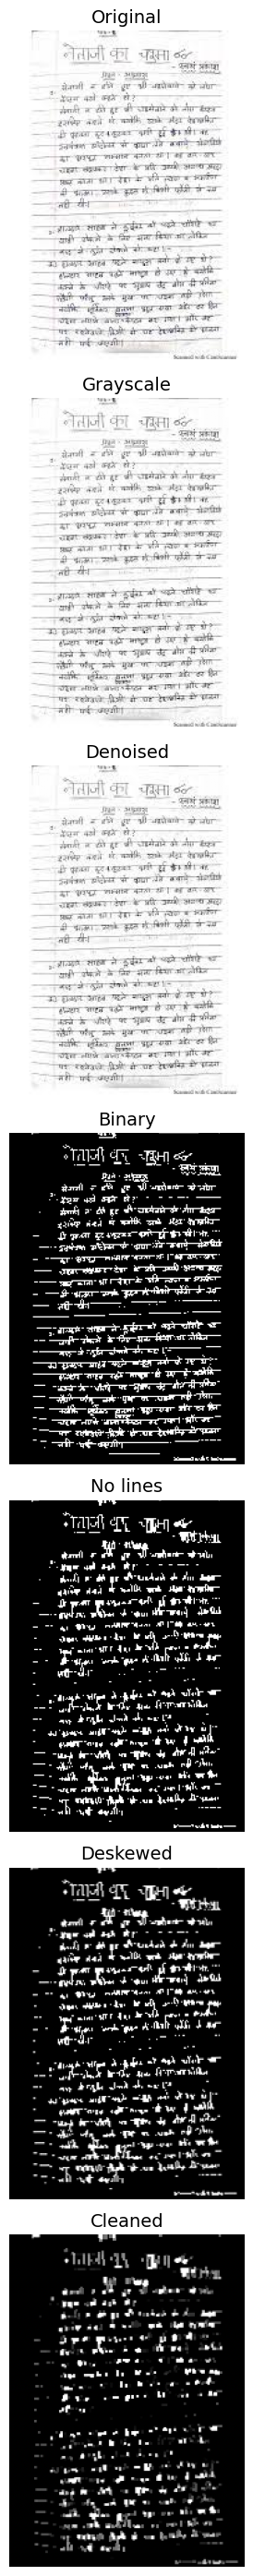

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_steps(image_path):
    """
    Load an image and perform preprocessing steps:
    1. Load
    2. Grayscale
    3. Denoise
    4. Binarize (Otsu’s, inverted)
    5. Remove notebook lines
    6. Deskew
    7. Morphological clean
    Returns dict of intermediate images.
    """
    steps = {}
    # 1. Load BGR image
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Unable to load '{image_path}'")
    steps['original'] = img.copy()

    # 2. Grayscale conversion
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    steps['grayscale'] = gray.copy()

    # 3. Denoising (Gaussian blur)
    # denoised = cv2.GaussianBlur(gray, (5, 5), 0)
    denoised = gray
    steps['denoised'] = denoised.copy()

    # 4. Binarization (Otsu’s thresholding, inverted)
    _, binary = cv2.threshold(
        denoised, 0, 255,
        cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    steps['binary'] = binary.copy()

    # 5. Notebook-line removal
    # a) Detect long horizontal lines
    horiz_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (binary.shape[1] // 30, 1))
    detected_lines = cv2.morphologyEx(
        binary, cv2.MORPH_OPEN, horiz_kernel, iterations=2)
    # b) Subtract lines
    mask = cv2.bitwise_not(detected_lines)
    no_lines = cv2.bitwise_and(binary, binary, mask=mask)
    # c) Reconnect any broken strokes vertically
    vert_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (1, 3))
    cleaned_lines = cv2.morphologyEx(
        no_lines, cv2.MORPH_CLOSE, vert_kernel, iterations=1)
    steps['no_lines'] = cleaned_lines.copy()

    # 6. Deskewing
    coords = np.column_stack(np.where(cleaned_lines > 0))
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle += 90
    (h, w) = cleaned_lines.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    deskewed = cv2.warpAffine(
        cleaned_lines, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE)
    steps['deskewed'] = deskewed.copy()

    # 7. Morphological opening (remove small artifacts)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    cleaned = cv2.morphologyEx(
        deskewed, cv2.MORPH_OPEN, kernel)
    steps['cleaned'] = cleaned.copy()

    return steps

def show_preprocess_sequence_column(image_path):
    """
    Display each preprocessing stage one below the other in a column.
    """
    steps = preprocess_steps(image_path)
    titles = [
        'original', 'grayscale', 'denoised',
        'binary', 'no_lines', 'deskewed', 'cleaned'
    ]
    n = len(titles)
    plt.figure(figsize=(6, 4 * n))

    for i, title in enumerate(titles, start=1):
        plt.subplot(n, 1, i)
        img = steps[title]
        if title == 'original':
            img_disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img_disp)
        else:
            plt.imshow(img, cmap='gray')
        plt.title(title.replace('_', ' ').capitalize(), fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage:
show_preprocess_sequence_column('download.jpeg')
show_preprocess_sequence_column('images.jpeg')
